## Assignment
@Author: **xx**

In [222]:
# 
# Import necessary libraries
# 
import re
import itertools
import numpy as np
import pandas as pd

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

from sklearn.svm import LinearSVC
from scipy.sparse import csr_matrix

from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


USER_NAMES = ["User1", "User2", "User3"]
M_VALUES = [10, 20, 40, 80, "all"]
MATCHING_ALGORITHMS = ["cosine", "euclidean"]
TOP_N_PER_GENRE = 10


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/carside/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/carside/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/carside/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [223]:
# Import the dataset as dataframe first.
dataset = pd.read_csv("dataset.tsv", sep="\t")
dataset.head(3)

,authors,title,genre,summary
0,Suzanne Collins,"The Hunger Games (The Hunger Games, #1)",young_adult,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...
1,"J.K. Rowling, Mary GrandPré",Harry Potter and the Sorcerer's Stone (Harry P...,fantasy,Harry Potter's life is miserable. His parents ...
2,Stephenie Meyer,"Twilight (Twilight, #1)",young_adult,About three things I was absolutely positive. ...


In [224]:
df = pd.DataFrame({'book_content': dataset.summary, 'genre':dataset.genre})

df.head(2)

,book_content,genre
0,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,young_adult
1,Harry Potter's life is miserable. His parents ...,fantasy


### Part 1 - Q1

(i)

The original regex may be too aggressive 

because it removes all punctuation and special symbols by deletion. 

This can merge words and destroy informative genre-related expressions.

For example, "science-fiction" becomes "sciencefiction", which is no longer a valid word.

Instead, I will choose an empty space to replace punctuation and symbols, such that

merging words can be avoided.

(ii)

A single random training-test split is not reliable 

because the result may depend heavily on one particular split of the data. 

To obtain a more stable estimate of model performance, 

I have chosen stratified k-fold(k=5) cross-validation,

because it keeps the distribution approximately consistent across folds, which is better.

### Part 1 - Q2

To choose the best preprocessing strategy, 

I tested different combinations of 

special character handling, word definition, stopword removal, lowercasing, and 

stemming/lemmatization. 

Each setup was evaluated using stratified 5-fold cross-validation.

The best overall preprocessing setup was: 

1. lowercase the text, 

2. replace special characters with spaces, 

3. keep alphabetic words only, 

4. do not remove stopwords, 
5. and apply Porter stemming. 

Replacing special characters with spaces avoids incorrectly merging words.

With this preprocessing setup, 

BNB achieved a mean accuracy of 0.66525 with a standard deviation of 0.00917, 

while MNB achieved a mean accuracy of 0.72775 with a standard deviation of 0.01094. 

The overall mean accuracy was 0.69650, which was the best among the tested configurations. 

Therefore, I will use this preprocessing setup for the rest of the assignment.

In [225]:
# Stopword lists
nltk_stopwords = set(stopwords.words("english"))
sklearn_stopwords = set(ENGLISH_STOP_WORDS)

# Stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Text preprocessing function.
def preprocess_text(
    text,
    lowercase=True, char_mode="space",
    word_mode="alpha", stopword_mode="nltk", normalization_mode="stem"
):
    """
    Preprocess a text string before CountVectorizer.

    Parameters
    ----------
    lowercase:
        Whether to lowercase the text. CountVectorizer() also lowercases by default,
        but we keep this explicit for clarity.

    char_mode:
        "delete" -> remove special characters directly.
                    Example: science-fiction -> sciencefiction
        "space"  -> replace special characters with spaces.
                    Example: science-fiction -> science fiction

    word_mode:
        "alpha" -> keep alphabetic words only.
        "alnum" -> keep alphabetic and numeric tokens.

    stopword_mode:
        "none" -> do not remove stopwords.
        "nltk" -> remove NLTK English stopwords.
        "sklearn" -> remove scikit-learn English stopwords.

    normalization_mode:
        "none" -> no stemming or lemmatization.
        "stem" -> Porter stemming.
        "lemma" -> WordNet lemmatization.
    """

    # 1. Lowercasing the words.
    if lowercase:
        text = text.lower()

    # 2. Special character handling
    if char_mode == "delete":
        # directly delete special characters(Tutorial default setting, for comparison use)
        text = re.sub(r"[^A-Za-z0-9\s]", "", text)

    elif char_mode == "space":
        # replace special characters with spaces
        # science-fiction -> science fiction
        text = re.sub(r"[^A-Za-z0-9\s]", " ", text)

    else:
        raise ValueError("char_mode must be either 'delete' or 'space'.")

    # 3. word selection
    if word_mode == "alpha":
        # Alphabetic tokens only, length >= 2
        tokens = re.findall(r"\b[a-zA-Z]{2,}\b", text)

    elif word_mode == "alnum":
        # Alphabetic or numeric tokens, length >= 2
        tokens = re.findall(r"\b[a-zA-Z0-9]{2,}\b", text)

    else:
        raise ValueError("word_mode must be either 'alpha' or 'alnum'.")

    # 4. Stopword removal
    if stopword_mode == "nltk":
        tokens = [t for t in tokens if t not in nltk_stopwords]

    elif stopword_mode == "sklearn":
        tokens = [t for t in tokens if t not in sklearn_stopwords]

    elif stopword_mode == "none":
        pass

    else:
        raise ValueError("stopword_mode must be 'none', 'nltk', or 'sklearn'.")

    # 5. Stemming or lemmatization.
    if normalization_mode == "stem":
        tokens = [stemmer.stem(t) for t in tokens]

    elif normalization_mode == "lemma":
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    elif normalization_mode == "none":
        pass

    else:
        raise ValueError("normalization_mode must be 'none', 'stem', or 'lemma'.")

    return " ".join(tokens)

In [226]:
# Lowercasing is kept as True because CountVectorizer() lowercases by default.
# I still keep it here explicitly to make the preprocessing decision clear.

config_grid = {
    "lowercase": [True],
    "char_mode": ["delete", "space"],
    "word_mode": ["alpha", "alnum"],
    "stopword_mode": [ "nltk", "sklearn"],
    "normalization_mode": ["none", "stem", "lemma"]
}

preprocessing_configs = []

for values in itertools.product(*config_grid.values()):
    config = dict(zip(config_grid.keys(), values))
    preprocessing_configs.append(config)

print("Number of preprocessing configurations:", len(preprocessing_configs))
preprocessing_configs[:5]

Number of preprocessing configurations: 24


[{'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'nltk',
  'normalization_mode': 'none'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'nltk',
  'normalization_mode': 'stem'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'nltk',
  'normalization_mode': 'lemma'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'sklearn',
  'normalization_mode': 'none'},
 {'lowercase': True,
  'char_mode': 'delete',
  'word_mode': 'alpha',
  'stopword_mode': 'sklearn',
  'normalization_mode': 'stem'}]

In [227]:
bnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),   # default settings
    ("classifier", BernoulliNB())        # default settings
])

mnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),   # default settings
    ("classifier", MultinomialNB())      # default settings
])

# StratifiedKFold cross-validation k=5
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Change these column names if your dataframe uses different names
TEXT_COL = "book_content"
LABEL_COL = "genre"

# Make a clean copy for experiments
data = df[[TEXT_COL, LABEL_COL]].copy()

# Remove rows with missing text or label
data = data.dropna(subset=[TEXT_COL, LABEL_COL])

# Ensure text is string
data[TEXT_COL] = data[TEXT_COL].astype(str)

texts = data[TEXT_COL]
labels = data[LABEL_COL]

print("Number of samples:", len(data))
print("Genre distribution:")
print(labels.value_counts())

Number of samples: 4000
Genre distribution:
genre
fantasy        1158
classics        936
romance         692
young_adult     626
thriller        588
Name: count, dtype: int64


### Find the best config for text preprocessing.

In [228]:
results = []

for idx, config in enumerate(preprocessing_configs, start=1):
    print(f"Running config {idx}/{len(preprocessing_configs)}: {config}")

    # Apply preprocessing
    processed_texts = texts.apply(lambda x: preprocess_text(x, **config))

    # BernoulliNB cross-validation accuracy
    bnb_scores = cross_val_score(
        bnb_pipeline,
        processed_texts,
        labels,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # MultinomialNB cross-validation accuracy
    mnb_scores = cross_val_score(
        mnb_pipeline,
        processed_texts,
        labels,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    results.append({
        "lowercase": config["lowercase"],
        "char_mode": config["char_mode"],
        "word_mode": config["word_mode"],
        "stopword_mode": config["stopword_mode"],
        "normalization_mode": config["normalization_mode"],

        "bnb_mean_accuracy": bnb_scores.mean(),
        "bnb_std_accuracy": bnb_scores.std(),

        "mnb_mean_accuracy": mnb_scores.mean(),
        "mnb_std_accuracy": mnb_scores.std(),

        # Overall means we want a preprocessing setup that works well for both BNB and MNB
        "overall_mean_accuracy": (bnb_scores.mean() + mnb_scores.mean()) / 2
    })

results_df = pd.DataFrame(results)

# Sort by overall mean accuracy
results_df = results_df.sort_values(
    by="overall_mean_accuracy",
    ascending=False
).reset_index(drop=True)

results_df.head(10)

Running config 1/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'none'}


/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from 

Running config 2/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'stem'}


/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


Running config 3/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'lemma'}


/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/carside/miniconda3/envs/6713/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)


Running config 4/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'sklearn', 'normalization_mode': 'none'}
Running config 5/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'sklearn', 'normalization_mode': 'stem'}
Running config 6/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alpha', 'stopword_mode': 'sklearn', 'normalization_mode': 'lemma'}
Running config 7/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alnum', 'stopword_mode': 'nltk', 'normalization_mode': 'none'}
Running config 8/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alnum', 'stopword_mode': 'nltk', 'normalization_mode': 'stem'}
Running config 9/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alnum', 'stopword_mode': 'nltk', 'normalization_mode': 'lemma'}
Running config 10/24: {'lowercase': True, 'char_mode': 'delete', 'word_mode': 'alnum', 'stopword_mode': 'sklearn', 'normalization_mode': 'none'

,lowercase,char_mode,word_mode,stopword_mode,normalization_mode,bnb_mean_accuracy,bnb_std_accuracy,mnb_mean_accuracy,mnb_std_accuracy,overall_mean_accuracy
0,True,space,alpha,nltk,stem,0.65525,0.009792,0.73550,0.014908,0.695375
1,True,space,alnum,nltk,stem,0.65175,0.010914,0.73625,0.016956,0.694000
2,True,space,alpha,sklearn,stem,0.64700,0.007098,0.73825,0.014676,0.692625
3,True,space,alnum,sklearn,stem,0.64575,0.010356,0.73875,0.013323,0.692250
4,True,space,alpha,nltk,lemma,0.62975,0.015379,0.73425,0.015941,0.682000
5,True,space,alpha,sklearn,lemma,0.62350,0.016609,0.73675,0.014022,0.680125
6,True,space,alnum,nltk,lemma,0.62600,0.017596,0.73250,0.016808,0.679250
7,True,space,alnum,sklearn,lemma,0.61825,0.017847,0.73625,0.014513,0.677250
8,True,space,alpha,nltk,none,0.61225,0.016609,0.73375,0.011264,0.673000
9,True,space,alpha,sklearn,none,0.60400,0.013379,0.73800,0.009138,0.671000


#### Print out the best config

In [229]:
best_row = results_df.iloc[0]

best_config = {
    "lowercase": best_row["lowercase"],
    "char_mode": best_row["char_mode"],
    "word_mode": best_row["word_mode"],
    "stopword_mode": best_row["stopword_mode"],
    "normalization_mode": best_row["normalization_mode"]
}

print("Best preprocessing configuration:")
print(best_config)

print("\nPerformance of the best configuration:")
print("BNB mean accuracy:", best_row["bnb_mean_accuracy"])
print("BNB std accuracy:", best_row["bnb_std_accuracy"])
print("MNB mean accuracy:", best_row["mnb_mean_accuracy"])
print("MNB std accuracy:", best_row["mnb_std_accuracy"])
print("Overall mean accuracy:", best_row["overall_mean_accuracy"])

Best preprocessing configuration:
{'lowercase': np.True_, 'char_mode': 'space', 'word_mode': 'alpha', 'stopword_mode': 'nltk', 'normalization_mode': 'stem'}

Performance of the best configuration:
BNB mean accuracy: 0.65525
BNB std accuracy: 0.009791578013783062
MNB mean accuracy: 0.7354999999999999
MNB std accuracy: 0.014908051515875553
Overall mean accuracy: 0.695375


### Part 1 - Q3

**About the training feature columns selection:**

For topic classification, I used the book `content` as the main document content and used genre as the target label. 

I did not include the `author` field because it may allow the model to learn author-specific shortcuts 

rather than general genre-related textual patterns. 

I also did not include the `title` in the main experiments 

to keep the input representation focused on the `content` text.

**Notes:**

I compared BNB and MNB with stratified 5-fold cross-validation. 

I used the preprocessing setup selected in Q2 for both models.

**Dataset balance and metric tradeoffs:**

The dataset is moderately imbalanced: the largest class is `fantasy` with 1158 books, 

while the smallest class is `thriller` with 588 books. 

Accuracy is useful for measuring overall correctness, 

but it can be influenced by larger classes. 

Weighted F1 also reflects overall performance, but it gives more weight to larger classes. 

Macro F1 and balanced accuracy treat each genre more equally, 

so they are more useful for checking whether the model performs well across both large and small classes. 

Precision and recall are useful for understanding class-level behaviour, 

but F1 is a better single summary because it balances both.

**Justification of main metrics:**

I use accuracy as the main overall metric because the question asks for overall classification performance. 

However, because the dataset is moderately imbalanced, 

I also use macro F1 and balanced accuracy as supporting main metrics. 

These metrics help ensure that a model is not only performing well on the larger genres, 

but also has reasonable performance across the smaller genres.

**Results and conclusion:**

The results show that MNB is superior overall. 

As shown in the metric comparison table and plot, 

BNB achieved an accuracy of 0.67, macro F1 of 0.64, balanced accuracy of 0.62, and weighted F1 of 0.66. 

MNB achieved higher scores, with an accuracy of 0.73, macro F1 of 0.72, balanced accuracy of 0.71, and weighted F1 of 0.73. 

This improvement is not only in overall accuracy, 

but also in metrics that account for class imbalance.

The classification reports and confusion matrices support my conclusion. 

BNB has high recall for `fantasy`, but it misclassifies many `young_adult`, `thriller`, and `romance` books as `fantasy`. 

For example, 284 `young_adult` books and 201 `thriller` books were predicted as `fantasy`, 

which leads to low recall for these classes. 

In contrast, 

MNB gives more balanced predictions across genres and improves the recall of `romance`, `thriller`, and `young_adult`. 

Although BNB performs slightly better on `classics`, 

MNB is superior overall because it achieves higher accuracy, macro F1, balanced accuracy, and weighted F1.


#### Use the best config to preprocess the book dataset.

In [230]:
# Use the same text and label columns as before
TEXT_COL = "book_content"
LABEL_COL = "genre"

# Make sure the selected preprocessing from Q2 is fixed
best_config = {
    "lowercase": True,
    "char_mode": "space",
    "word_mode": "alpha",
    # "stopword_mode": "none",
    "stopword_mode": "nltk",
    "normalization_mode": "stem"
}

data = df[[TEXT_COL, LABEL_COL]].copy()

# Apply the selected preprocessing to the full dataset
data["processed_book_content"] = data[TEXT_COL].apply(
    lambda x: preprocess_text(x, **best_config)
)

X_text = data["processed_book_content"]
y = data[LABEL_COL]

print("Number of samples:", len(data))
print("Number of genres:", y.nunique())
print(y.value_counts())

Number of samples: 4000
Number of genres: 5
genre
fantasy        1158
classics        936
romance         692
young_adult     626
thriller        588
Name: count, dtype: int64


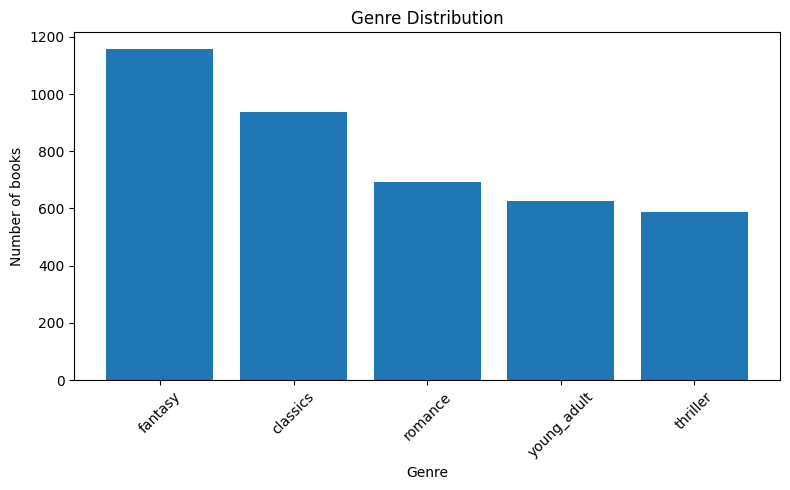

In [231]:
genre_counts = y.value_counts()

genre_distribution = pd.DataFrame({
    "genre": genre_counts.index,
    "count": genre_counts.values,
    "percentage": genre_counts.values / genre_counts.values.sum()
})

plt.figure(figsize=(8, 5))
plt.bar(genre_distribution["genre"], genre_distribution["count"])
plt.xlabel("Genre")
plt.ylabel("Number of books")
plt.title("Genre Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### BNB and MNB pipeline setup & StratifiedKFold cross-validation

In [232]:
bnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", BernoulliNB())
])

mnb_pipeline = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Evaluate multiple classification metrics for BNB & MNB

In [233]:
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

bnb_cv_results = cross_validate(
    bnb_pipeline,
    X_text,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

mnb_cv_results = cross_validate(
    mnb_pipeline,
    X_text,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

#### Create comparison table for BNB and MNB metric results.

In [234]:
def summarize_cv_results(cv_results, model_name):
    summary = {"model": model_name}
    
    for metric in scoring.keys():
        scores = cv_results[f"test_{metric}"]
        summary[f"{metric}_mean"] = scores.mean()
        summary[f"{metric}_std"] = scores.std()
    
    return summary


comparison_df = pd.DataFrame([
    summarize_cv_results(bnb_cv_results, "BernoulliNB"),
    summarize_cv_results(mnb_cv_results, "MultinomialNB")
])

comparison_df

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,BernoulliNB,0.65525,0.009792,0.604686,0.009707,0.756992,0.011134,0.604686,0.009707,0.631507,0.009885,0.644651,0.009840
1,MultinomialNB,0.73550,0.014908,0.721185,0.015362,0.746287,0.015098,0.721185,0.015362,0.726599,0.014340,0.735246,0.014364


#### Plot the metric comparison

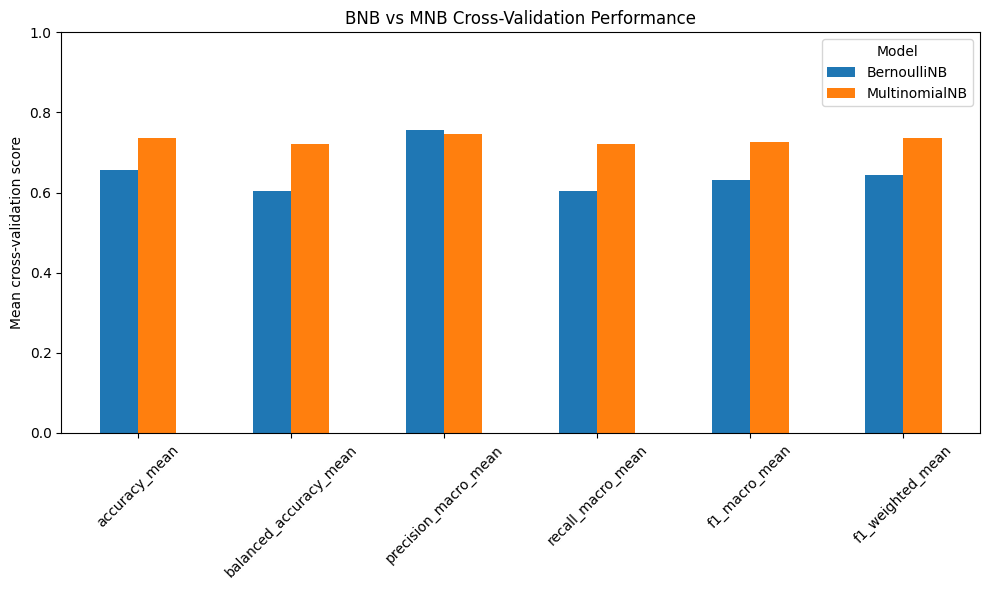

In [235]:
plot_df = comparison_df.set_index("model")[
    [
        "accuracy_mean",
        "balanced_accuracy_mean",
        "precision_macro_mean",
        "recall_macro_mean",
        "f1_macro_mean",
        "f1_weighted_mean"
    ]
]
plot_df.T.plot(kind="bar", figsize=(10, 6))
plt.ylabel("Mean cross-validation score")
plt.title("BNB vs MNB Cross-Validation Performance")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [236]:
bnb_pred = cross_val_predict(
    bnb_pipeline,
    X_text,
    y,
    cv=cv,
    n_jobs=-1
)

mnb_pred = cross_val_predict(
    mnb_pipeline,
    X_text,
    y,
    cv=cv,
    n_jobs=-1
)

print("BernoulliNB Classification Report")
print(classification_report(y, bnb_pred))

print("MultinomialNB Classification Report")
print(classification_report(y, mnb_pred))

BernoulliNB Classification Report
              precision    recall  f1-score   support

    classics       0.73      0.78      0.76       936
     fantasy       0.52      0.88      0.65      1158
     romance       0.76      0.56      0.65       692
    thriller       0.93      0.47      0.62       588
 young_adult       0.84      0.34      0.48       626

    accuracy                           0.66      4000
   macro avg       0.76      0.60      0.63      4000
weighted avg       0.72      0.66      0.64      4000

MultinomialNB Classification Report
              precision    recall  f1-score   support

    classics       0.80      0.72      0.76       936
     fantasy       0.75      0.82      0.78      1158
     romance       0.60      0.78      0.68       692
    thriller       0.80      0.71      0.75       588
 young_adult       0.78      0.58      0.67       626

    accuracy                           0.74      4000
   macro avg       0.75      0.72      0.73      4000
weighte

#### Confusion matrices for BNB and MNB

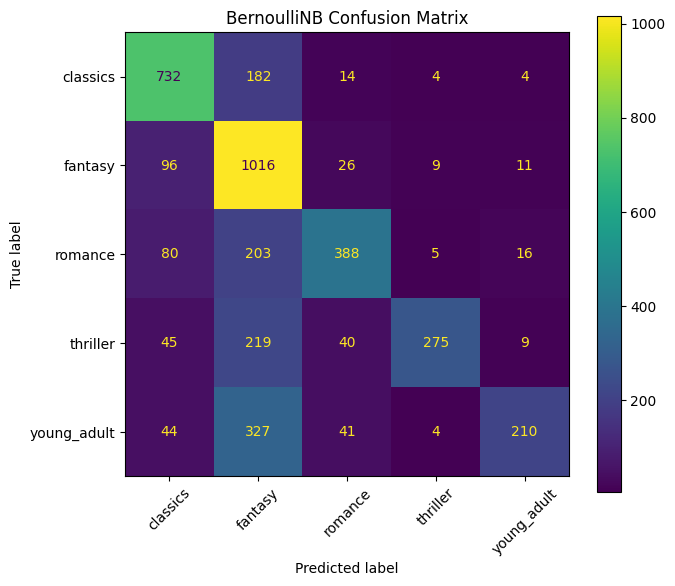

In [237]:
labels_order = sorted(y.unique())

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    bnb_pred,
    labels=labels_order,
    xticks_rotation=45,
    ax=ax
)
plt.title("BernoulliNB Confusion Matrix")
plt.tight_layout()
plt.show()

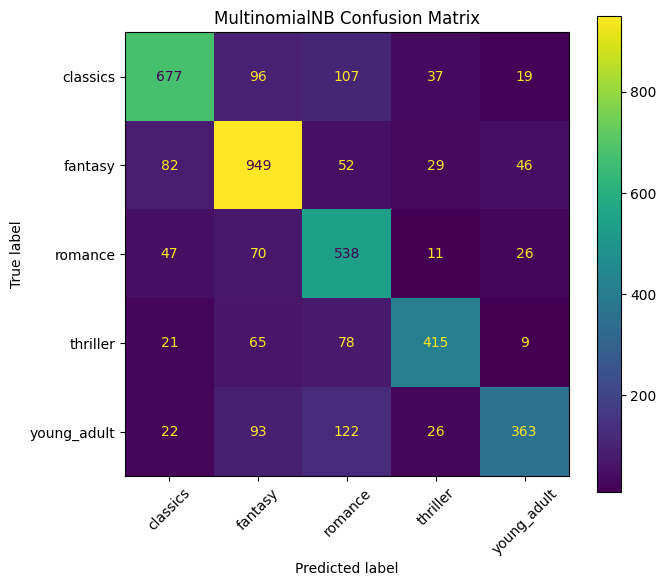

In [238]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y,
    mnb_pred,
    labels=labels_order,
    xticks_rotation=45,
    ax=ax
)
plt.title("MultinomialNB Confusion Matrix")
plt.tight_layout()
plt.show()

### Part 1 - Q4

I used the preprocessing setup selected in Q2 and evaluated both BNB and MNB with stratified 5-fold cross-validation. 

I tested N values from 500 to 19,500 in steps of 500.

The plots show that both accuracy and macro F1 increase quickly when N is small, 

because the models gain more useful words for classification. 

After around 7,500 to 10,000 features, the improvement becomes much smaller. 

MNB remains stable at larger N values, while BNB starts to decline when too many features are included, 

suggesting that extra low-frequency words may add noise.

To choose a value that works well overall, 

I used an overall score based on the average of mean accuracy, mean macro F1, and mean balanced accuracy across both models. 

The best value is `N = 8500`. At this value, the mean accuracy across models was 0.717875, 

the mean macro F1 was 0.711487, 

the mean balanced accuracy was 0.706936, and the overall score was 0.712099.

Therefore, I selected `max_features=8500` for the rest of the assignment. 


In [239]:
N_values = np.arange(500,20000,500)

models = {
    "BernoulliNB": BernoulliNB(),
    "MultinomialNB": MultinomialNB()
}

feature_results = []

for N in N_values:
    for model_name, classifier in models.items():
        
        pipe = Pipeline([
            ("vectorizer", CountVectorizer(max_features=N)),
            ("classifier", classifier)
        ])
        
        cv_results = cross_validate(
            pipe,
            X_text,
            y,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=False
        )
        
        feature_results.append({
            "N": N,
            "model": model_name,
            "accuracy_mean": cv_results["test_accuracy"].mean(),
            "accuracy_std": cv_results["test_accuracy"].std(),
            "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
            "balanced_accuracy_std": cv_results["test_balanced_accuracy"].std(),
            "f1_macro_mean": cv_results["test_f1_macro"].mean(),
            "f1_macro_std": cv_results["test_f1_macro"].std(),
            "f1_weighted_mean": cv_results["test_f1_weighted"].mean(),
            "f1_weighted_std": cv_results["test_f1_weighted"].std()
        })

feature_results_df = pd.DataFrame(feature_results)

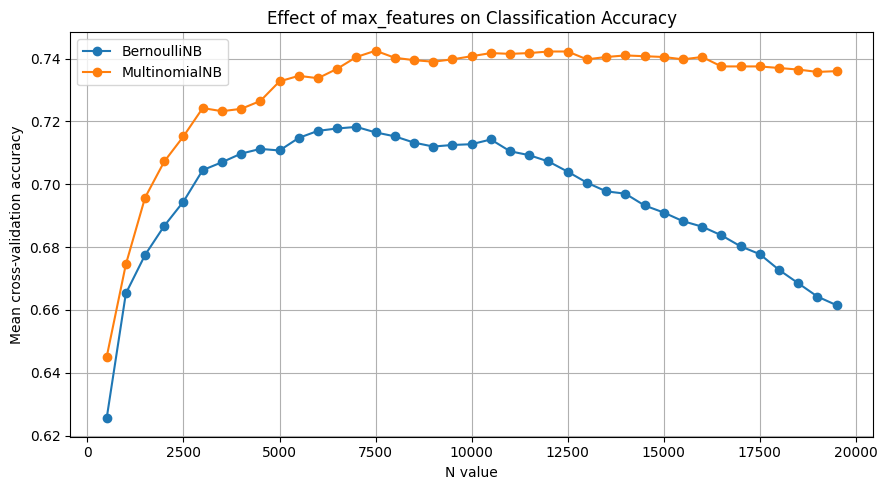

In [240]:
plt.figure(figsize=(9, 5))

for model_name in models.keys():
    model_df = feature_results_df[feature_results_df["model"] == model_name]
    plt.plot(
        model_df["N"],
        model_df["accuracy_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("N value")
plt.ylabel("Mean cross-validation accuracy")
plt.title("Effect of Number of features N")
plt.ylabel("Mean cross-validation accuracy")
plt.title("Effect of max_features on Classification Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

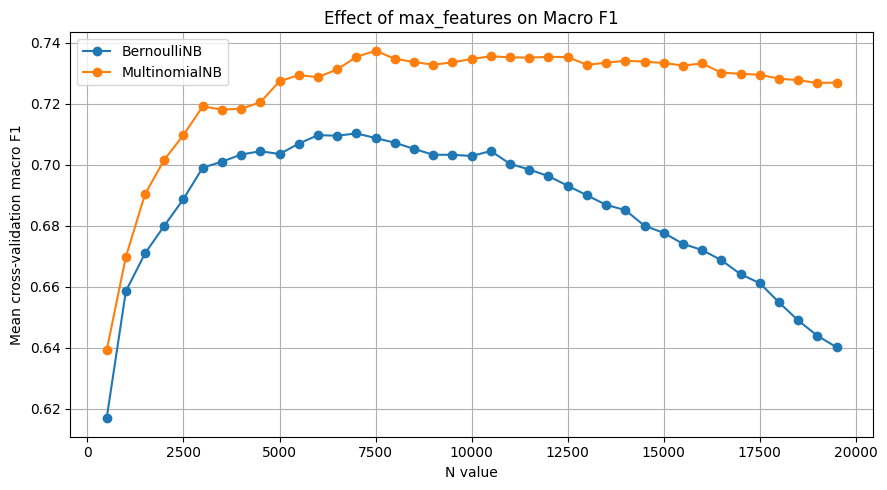

In [241]:
plt.figure(figsize=(9, 5))

for model_name in models.keys():
    model_df = feature_results_df[feature_results_df["model"] == model_name]
    plt.plot(
        model_df["N"],
        model_df["f1_macro_mean"],
        marker="o",
        label=model_name
    )

plt.xlabel("N value")
plt.ylabel("Mean cross-validation macro F1")
plt.title("Effect of max_features on Macro F1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Find the best N value that works well overall:

In [242]:
selection_table = feature_results_df.groupby("N").agg(
    mean_accuracy_across_models=("accuracy_mean", "mean"),
    mean_macro_f1_across_models=("f1_macro_mean", "mean"),
    mean_balanced_accuracy_across_models=("balanced_accuracy_mean", "mean")
).reset_index()

# selection criterion: average accuracy across both models
selection_table = selection_table.sort_values(
    by="mean_accuracy_across_models",
    ascending=False
).reset_index(drop=True)

selection_table["overall_score"] = (
    selection_table["mean_accuracy_across_models"]
    + selection_table["mean_macro_f1_across_models"]
    + selection_table["mean_balanced_accuracy_across_models"]
) / 3

selection_table = selection_table.sort_values(
    by="overall_score",
    ascending=False
).reset_index(drop=True)

best_N = int(selection_table.iloc[0]["N"])

print("Selected N:", best_N)
print(selection_table.iloc[0])

Selected N: 7500
N                                       7500.000000
mean_accuracy_across_models                0.729500
mean_macro_f1_across_models                0.723006
mean_balanced_accuracy_across_models       0.718087
overall_score                              0.723531
Name: 0, dtype: float64


### Part 1 Q5

#### Another machine learning method: SVM

For the additional machine learning method, I chose SVM, implemented using `LinearSVC` from sklearn. 

##### Summary

A linear SVM is a discriminative classifier that learns linear decision boundaries between classes. 

For text classification, documents are usually represented as high-dimensional sparse word vectors, 

and linear SVMs are suitable for this setting 

because they can separate classes using weighted combinations of words. 

This makes LinearSVC a reasonable method for book genre classification.

##### My hypothesis

I used the same preprocessing setup selected earlier and the same `CountVectorizer(max_features=7500)` representation as BNB and MNB. 

The main hyperparameter of LinearSVC is `C`, which controls the strength of regularization. 

Smaller `C` values apply stronger regularization, while larger values fit the training data more closely and may overfit. 

I tested `different C values` using stratified 5-fold cross-validation. The best LinearSVC setting was `C = 0.005`, with accuracy 0.72525, balanced accuracy 0.70905, macro F1 0.71704, and overall score 0.71711.

My hypothesis was that 

LinearSVC would outperform BNB and might also outperform MNB, 

because it does not rely on the Naive Bayes word-independence assumption.

#### Results 

The hypothesis was only partially confirmed. 

LinearSVC performed better than BNB, but it did not outperform MNB. 

As shown in the final comparison plot, MNB still achieved the best overall performance.

So, the best overall method for topic classification is MNB with the selected preprocessing setup and `CountVectorizer(max_features=8500)`. 

LinearSVC is competitive and improves over BNB, but MNB remains the best choice for this dataset, 

probably because it is naturally well suited to count-based word features. 

Also,I would like to point out that LinearSVC may perform better with TF-IDF features rather than raw count features. 

This is because TF-IDF reduces the influence of very frequent but less informative words and normalizes the importance of 

terms across documents, which usually works well with linear margin-based classifiers such as SVM. 

In contrast, the current experiment uses count-based features, which are naturally well matched to MNB.


In [243]:
C_values = [0.0005, 0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1]
svc_results = []

for C in C_values:
    svc_pipeline = Pipeline([
        ("vectorizer", CountVectorizer(max_features=best_N)),
        ("classifier", LinearSVC(C=C, max_iter=20000, random_state=42))
    ])
    
    cv_results = cross_validate(
        svc_pipeline,
        X_text, y,
        cv=cv, scoring=scoring, n_jobs=-1,
        return_train_score=False
    )
    
    svc_results.append({
        "C": C,
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "precision_macro_mean": cv_results["test_precision_macro"].mean(),
        "recall_macro_mean": cv_results["test_recall_macro"].mean(),
        "f1_macro_mean": cv_results["test_f1_macro"].mean(),
    })

svc_results_df = pd.DataFrame(svc_results)

# Overall score: average of accuracy, macro F1 and balanced accuracy
svc_results_df["overall_score"] = (
    svc_results_df["accuracy_mean"]
    + svc_results_df["f1_macro_mean"]
    + svc_results_df["balanced_accuracy_mean"]
) / 3

svc_results_df = svc_results_df.sort_values(
    by="overall_score",
    ascending=False
).reset_index(drop=True)

best_C = svc_results_df.iloc[0]["C"]

print("Best C for LinearSVC:", best_C)
print(svc_results_df.iloc[0])

Best C for LinearSVC: 0.005
C                         0.005000
accuracy_mean             0.725250
balanced_accuracy_mean    0.709050
precision_macro_mean      0.732238
recall_macro_mean         0.709050
f1_macro_mean             0.717036
overall_score             0.717112
Name: 0, dtype: float64


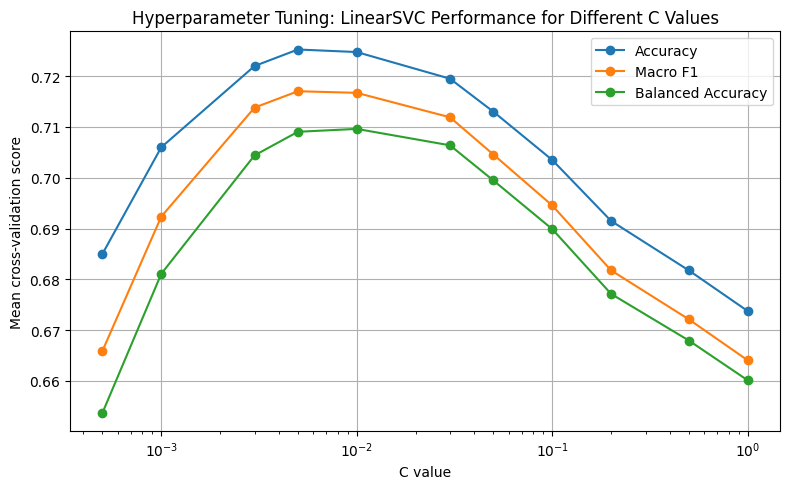

In [244]:
plt.figure(figsize=(8, 5))

svc_plot_df = svc_results_df.sort_values("C")
plt.plot(svc_plot_df["C"], svc_plot_df["accuracy_mean"], marker="o", label="Accuracy")
plt.plot(svc_plot_df["C"], svc_plot_df["f1_macro_mean"], marker="o", label="Macro F1")
plt.plot(svc_plot_df["C"], svc_plot_df["balanced_accuracy_mean"], marker="o", label="Balanced Accuracy")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Mean cross-validation score")
plt.title("Hyperparameter Tuning: LinearSVC Performance for Different C Values")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Compare BNB, MNB and best LinearSVC

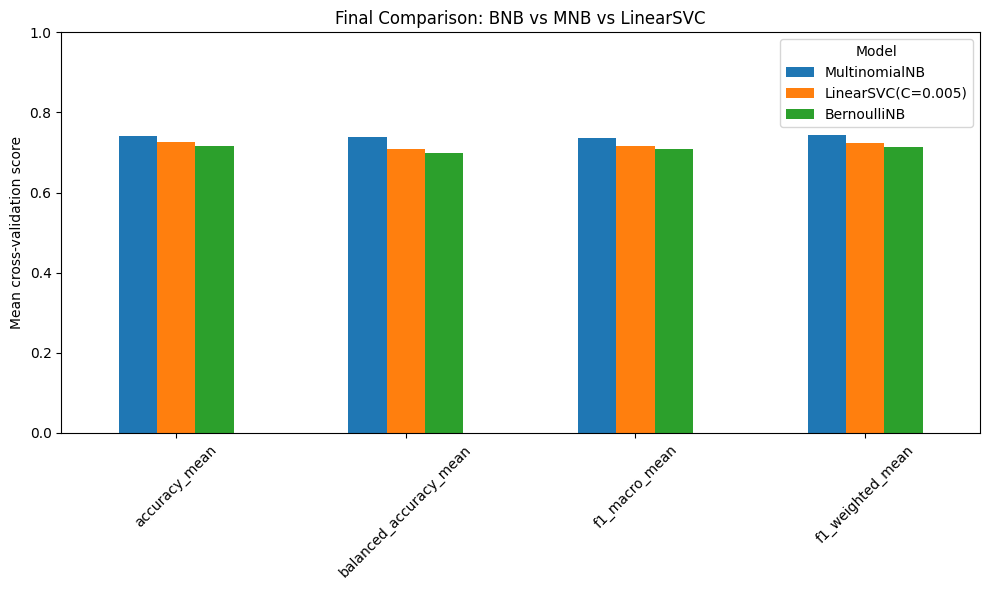

In [245]:
models = {
    "BernoulliNB": BernoulliNB(),
    "MultinomialNB": MultinomialNB(),
    f"LinearSVC(C={best_C})": LinearSVC(C=best_C, max_iter=20000, random_state=42)
}

final_results = []

for model_name, classifier in models.items():
    pipe = Pipeline([
        ("vectorizer", CountVectorizer(max_features=best_N)),
        ("classifier", classifier)
    ])
    
    cv_results = cross_validate(
        pipe,
        X_text,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    final_results.append({
        "model": model_name,
        "accuracy_mean": cv_results["test_accuracy"].mean(),
        "balanced_accuracy_mean": cv_results["test_balanced_accuracy"].mean(),
        "f1_macro_mean": cv_results["test_f1_macro"].mean(),
        "f1_weighted_mean": cv_results["test_f1_weighted"].mean(),
    })

final_results_df = pd.DataFrame(final_results)

final_results_df["overall_score"] = (
    final_results_df["accuracy_mean"]
    + final_results_df["f1_macro_mean"]
    + final_results_df["balanced_accuracy_mean"]
) / 3

final_results_df = final_results_df.sort_values(
    by="overall_score",
    ascending=False
).reset_index(drop=True)

plot_df = final_results_df.set_index("model")[
    [
        "accuracy_mean",
        "balanced_accuracy_mean",
        "f1_macro_mean",
        "f1_weighted_mean"
    ]
]

plot_df.T.plot(kind="bar", figsize=(10, 6))

plt.ylabel("Mean cross-validation score")
plt.title("Final Comparison: BNB vs MNB vs LinearSVC")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

## Part 2 Recommendation methods

### (Step 1/6) Predict genre by using best classifier(MNB) in part 1


In [246]:
books = dataset.copy()
# Use the column `summary` as the book content
books["book_content"] = books["summary"].fillna("").astype(str)

# Apply the same preprocessing in Part 1
books["processed_book_content"] = books["book_content"].apply( lambda x: preprocess_text(x, **best_config) )

# Weeks 1-3: books 0-2999 for training
train_books = books.iloc[:3000].copy()
# Week 4: books 3000-3999 for testing
test_books = books.iloc[3000:4000].copy()

# Part 1 best classifier MNB setup
genre_classifier = Pipeline([
    ("vectorizer", CountVectorizer(max_features=best_N)),
    ("classifier", MultinomialNB())
])

X_train = train_books["processed_book_content"]
y_train = train_books["genre"]

X_test = test_books["processed_book_content"]
y_test = test_books["genre"]

# Train MNB classifier on books of week 1-3.
genre_classifier.fit(X_train, y_train)

# genre prediction
train_books["predicted_genre"] = genre_classifier.predict(X_train)
test_books["predicted_genre"] = genre_classifier.predict(X_test)

train_pred = train_books["predicted_genre"]

print(f"Training accuracy:{accuracy_score(y_train, train_pred):.3f}" )


Training accuracy:0.910


#### Part 2 Q1(step 2/6) Build genre-specific TFIDF vector matrix for training dataset( week1-3 books)

In [247]:
print("Predicted genre distribution in training data:")
print(train_books["predicted_genre"].value_counts())

Predicted genre distribution in training data:
predicted_genre
fantasy        854
classics       719
romance        518
young_adult    500
thriller       409
Name: count, dtype: int64


In [248]:
genre_vectorizers = {}
genre_tfidf_matrices = {}
genre_train_books = {}
predicted_genres = train_books["predicted_genre"].unique()

for genre in predicted_genres:
    # Select training books predicted to be in this genre
    genre_books = train_books[train_books["predicted_genre"] == genre].copy()
    
    # Store the subset for later use
    genre_train_books[genre] = genre_books
    
    # Create a TfidfVectorizer for this predicted genre
    vectorizer = TfidfVectorizer()
    
    # Fit the vectorizer on books predicted to be in this genre
    tfidf_matrix = vectorizer.fit_transform(
        genre_books["processed_book_content"]
    )
    
    # Store vectorizer and matrix
    genre_vectorizers[genre] = vectorizer
    genre_tfidf_matrices[genre] = tfidf_matrix
    
    print(f"genre: {genre}")
    print(f"- Number of books: {genre_books.shape[0]}")
    print(f"- TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"- Vocabulary size: {len(vectorizer.get_feature_names_out())}")

genre: young_adult
- Number of books: 500
- TF-IDF matrix shape: (500, 5956)
- Vocabulary size: 5956
genre: fantasy
- Number of books: 854
- TF-IDF matrix shape: (854, 9490)
- Vocabulary size: 9490
genre: classics
- Number of books: 719
- TF-IDF matrix shape: (719, 9505)
- Vocabulary size: 9505
genre: thriller
- Number of books: 409
- TF-IDF matrix shape: (409, 6757)
- Vocabulary size: 6757
genre: romance
- Number of books: 518
- TF-IDF matrix shape: (518, 7334)
- Vocabulary size: 7334


#### Part 2 Q1 step 3/6) Use user keywords to simulate liked books

In [249]:
# Load user keyword file.
def load_user_keywords(filepath):
    user_keywords = {}
    
    with open(filepath, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            
            if not line:
                continue
            
            words = line.split("\t")
            genre = words[0].strip().lower()
            
            # Join all remaining columns as keyword text for each genre.
            keyword_text = " ".join(words[1:]).strip()
            user_keywords[genre] = keyword_text
    
    return user_keywords

# invoke the function to load keywords for 2 users.
user1_keywords_raw = load_user_keywords("user1.tsv")
user2_keywords_raw = load_user_keywords("user2.tsv")

# Preprocess the user keywords with the same text preprocessing as the book content.
def preprocess_user_keywords(user_keywords_raw, best_config):
   
    processed_keywords = {}
    
    for genre, keyword_text in user_keywords_raw.items():
        processed_text = preprocess_text(keyword_text, **best_config)
        keyword_tokens = set(processed_text.split())
        processed_keywords[genre] = keyword_tokens
    
    return processed_keywords

# invoke the function to preprocess the user's keywords.
user1_keywords = preprocess_user_keywords(user1_keywords_raw, best_config)
user2_keywords = preprocess_user_keywords(user2_keywords_raw, best_config)


# liked book mathcing rule: Matched if the processed book text contains at least one keyword.
def book_matches_keywords(book_text, keyword_tokens):
    book_tokens = set(str(book_text).split())
    return len(book_tokens.intersection(keyword_tokens)) > 0


"""
    Simulate liked books for one user.
    
    For each genre:
    - select training books predicted to be in that genre
    - check whether the processed book content matches the user's keywords
    - return matched books as liked books
"""
def find_liked_books_by_genre(train_books, user_keywords, which_user):
    
    liked_books_by_genre = {}
    
    for genre, keyword_tokens in user_keywords.items():
        # Only consider books predicted to be in this genre
        candidate_books = train_books[
            train_books["predicted_genre"] == genre
        ].copy()
        
        # Find books that match the user's keywords
        liked_mask = candidate_books["processed_book_content"].apply(
            lambda text: book_matches_keywords(text, keyword_tokens)
        )
        
        liked_books = candidate_books[liked_mask].copy()
        
        liked_books_by_genre[genre] = liked_books
        
        print(f"Genre: {genre}")
        print(f"{which_user}  Keywords: {sorted(keyword_tokens)}")
        print(f"  Candidate books predicted as {genre}: {len(candidate_books)}")
        print(f"  Liked books matched: {len(liked_books)}")
        print()
    
    return liked_books_by_genre

user1_liked_books = find_liked_books_by_genre(train_books, user1_keywords, "User 1")
user2_liked_books = find_liked_books_by_genre(train_books, user2_keywords, "User 2")

Genre: young_adult
User 1  Keywords: ['board', 'chosen', 'one', 'orphan', 'school']
  Candidate books predicted as young_adult: 500
  Liked books matched: 274

Genre: fantasy
User 1  Keywords: ['dragon', 'elv', 'kingdom', 'quest', 'wizard']
  Candidate books predicted as fantasy: 854
  Liked books matched: 196

Genre: romance
User 1  Keywords: ['duke', 'husband', 'marriag', 'regenc']
  Candidate books predicted as romance: 518
  Liked books matched: 112

Genre: classics
User 1  Keywords: ['introduct', 'literatur', 'masterpiec', 'translat']
  Candidate books predicted as classics: 719
  Liked books matched: 190

Genre: thriller
User 1  Keywords: ['detect', 'inspector', 'investig']
  Candidate books predicted as thriller: 409
  Liked books matched: 110

Genre: fantasy
User 2  Keywords: ['mysteri', 'power', 'supernatur', 'vampir']
  Candidate books predicted as fantasy: 854
  Liked books matched: 388

Genre: thriller
User 2  Keywords: ['assassin', 'conspiraci', 'evil', 'murder', 'polit']


#### Part2 Q1(step 4/6): Build user profile vectors

In [250]:
# Combine all liked books in one genre into one large document.
def combine_liked_books_text(liked_books):
    
    if liked_books is None or len(liked_books) == 0:
        return ""
    
    return " ".join(liked_books["processed_book_content"].astype(str).tolist())


# Build one user profile vector for each genre.
def build_user_profile_vectors(liked_books_by_genre, genre_vectorizers, predicted_genres):
    user_profile_vectors = {}
    summary_rows = []
    
    for genre in predicted_genres:
        # Get liked books for this genre
        liked_books = liked_books_by_genre.get(genre, pd.DataFrame())
        
        # Combine liked books into one large document
        combined_doc = combine_liked_books_text(liked_books)
        
        # Use the genre-specific vectorizer
        vectorizer = genre_vectorizers[genre]
        
        # Transform the combined document into a tf-idf vector
        profile_vector = vectorizer.transform([combined_doc])
        
        # Store profile vector
        user_profile_vectors[genre] = profile_vector
        
        # Store summary information
        summary_rows.append({
            "genre": genre,
            "liked_books_count": len(liked_books),
            "profile_vector_shape": profile_vector.shape,
            "vocabulary_size": len(vectorizer.get_feature_names_out())
        })
    
    profile_summary = pd.DataFrame(summary_rows)
    
    return user_profile_vectors, profile_summary


user1_profile_vectors, user1_profile_summary = build_user_profile_vectors(
    liked_books_by_genre=user1_liked_books,
    genre_vectorizers=genre_vectorizers,
    predicted_genres=predicted_genres
)

user2_profile_vectors, user2_profile_summary = build_user_profile_vectors(
    liked_books_by_genre=user2_liked_books,
    genre_vectorizers=genre_vectorizers,
    predicted_genres=predicted_genres
)

print("User 1 profile summary:")
user1_profile_summary

User 1 profile summary:


,genre,liked_books_count,profile_vector_shape,vocabulary_size
0,young_adult,274,"(1, 5956)",5956
1,fantasy,196,"(1, 9490)",9490
2,classics,190,"(1, 9505)",9505
3,thriller,110,"(1, 6757)",6757
4,romance,112,"(1, 7334)",7334


#### Part2 Q1 step 5/6) Print the top 20 words in two profiles for each genre

**Comments on top words**

Overall, the generated profile words are mostly reasonable. **(Please see the printed results in the section below)**

For User 1, the `fantasy` profile contains words such as 

`dragon`, `wizard`, `kingdom`, `quest`, `magic`, `power`, `dark`, `evil`, and `queen`, 

which clearly match fantasy themes. 

The `thriller` profile is also reasonable 

because it includes words such as `murder`, `investig`, `case`, `detect`, `killer`, `polic`, `mysteri`, `crime`, and `death`. 

The `romance` profile contains expected words such as `love`, `marriag`, `husband`, `wife`, `famili`, `heart`, `friend`, and `woman`. 

The `young_adult` profile is also plausible, 

with words such as `school`, `friend`, `girl`, `secret`, `life`, and `vampir`, 

which are common in young adult fiction. 

The `classics` profile is slightly less topic-specific, 

but still reasonable because it contains words such as `novel`, `literatur`, `classic`, `masterpiec`, `reader`, `play`, and `publish`.

###############################

For User 2, 

the `fantasy` and `thriller` profiles are reasonable. 

The fantasy profile includes words such as `power`, `vampir`, `world`, `dark`, `magic`, `secret`, `war`, and `human`, 

while the thriller profile includes `murder`, `killer`, `case`, `kill`, `mysteri`, `polic`, `detect`, `investig`, and `crime`. 

These words match the expected themes of those genres. 

Some less informative words also appear, such as `one`, `new`, `time`, `year`, `book`, and `stori`. 

These are not genre-specific and probably appear because they occur frequently in the liked books. 

Some proper names such as `harri`, `jack`, `alex`, `reacher`, and `lindsay` also appear. 

These may be reasonable if they come from influential books in the liked set, but they are less general than genre-level concepts. 



In [251]:
# Extract top weighted words from a user profile tf-idf vector.
def get_top_words_from_profile(profile_vector, vectorizer, top_n=20):

    feature_names = vectorizer.get_feature_names_out()

    # Convert sparse vector to dense 1D array
    weights = profile_vector.toarray().flatten()

    # If the profile has no non-zero terms, return empty dataframe
    if np.count_nonzero(weights) == 0:
        return pd.DataFrame(columns=["word", "tfidf_weight"])

    # Get indices of non-zero weights
    nonzero_indices = np.where(weights > 0)[0]

    # Sort non-zero indices by weight descending
    sorted_indices = nonzero_indices[np.argsort(weights[nonzero_indices])[::-1]]

    # Take top N
    top_indices = sorted_indices[:top_n]

    top_words_df = pd.DataFrame({
        "word": feature_names[top_indices],
        "tfidf_weight": weights[top_indices]
    })

    return top_words_df


def get_top_20_words(user_profile_vectors):
    user_top_words = {}
    for genre in predicted_genres:
        profile_vector = user_profile_vectors[genre]
        vectorizer = genre_vectorizers[genre]

        top_words_df = get_top_words_from_profile(
            profile_vector=profile_vector,
            vectorizer=vectorizer,
            top_n=20
        )

        user_top_words[genre] = top_words_df
    return user_top_words

user1_top_words = get_top_20_words(user1_profile_vectors)
user2_top_words = get_top_20_words(user2_profile_vectors)

In [252]:
def show_top_words(user_top_words, which_user):
    user_top_words_summary = []

    for genre, top_words_df in user_top_words.items():
        if top_words_df.empty:
            top_words = ""
        else:
            top_words = ", ".join(top_words_df["word"].tolist())

        user_top_words_summary.append({
            "user": which_user,
            "genre": genre,
            "top_20_words": top_words
        })

    return pd.DataFrame(user_top_words_summary)

user1_top_words_summary_df = show_top_words(user1_top_words, "User1")
user1_top_words_summary_df

,user,genre,top_20_words
0,User1,young_adult,"one, school, new, love, life, world, year, fri..."
1,User1,fantasy,"dragon, wizard, harri, kingdom, quest, magic, ..."
2,User1,classics,"edit, new, introduct, adventur, novel, literat..."
3,User1,thriller,"murder, investig, case, detect, killer, reache..."
4,User1,romance,"love, marriag, husband, life, stori, one, fami..."


In [253]:
user2_top_words_summary_df = show_top_words(user2_top_words, "User2")
user2_top_words_summary_df

,user,genre,top_20_words
0,User2,young_adult,
1,User2,fantasy,"power, vampir, one, world, mysteri, new, dark,..."
2,User2,classics,
3,User2,thriller,"murder, one, killer, case, new, reacher, year,..."
4,User2,romance,


#### Part2 Q1 step 6/6) Print and comment the top 20 words for User 3.

**I portrait User 3 with diverse interests across genres,** 

including social conflict and moral themes for classics, mythic adventure for fantasy, 

emotional conflict for romance, conspiracy and spy themes for thriller, and identity, friendship and survival themes for young adult. 

The matched liked books show that this profile was broad, 

with 226 matched classics books, 359 fantasy books, 202 romance books, 163 thriller books and 160 young adult books.

**The top words are reasonable, but they are broader and noisier than a more narrowly defined user profile.**

The fantasy profile contains words such as `world`, `power`, `god`, `battl`, `magic`, `ancient`, `dark`, `king`, `war` and `evil`, 

which match the intended mythic and adventure-based fantasy interests. 

The thriller profile is also reasonable, 

with words such as `secret`, `agent`, `murder`, `killer`, `reacher`, `cross` and `jack`, 

although some of these are character or series names rather than general genre concepts. 

The romance profile includes expected words such as `love`, `passion`, `friend`, `heart`, `woman` and `man`, 

while the young adult profile includes `surviv`, `friend`, `school`, `famili` and `friendship`.

Some words are less informative, such as `one`, `new`, `life`, `time`, `year`, `book` and `stori`. 

These appear because the simulated user matched many books, 

so the combined profile documents contain both interest-specific words and common book-summary words. 


In [254]:
user3_keywords_raw = {
    "classics": "society class poverty justice ambition tragedy moral family reputation inheritance",
    "fantasy": "myth prophecy sword curse empire monster portal gods battle ancient",
    "romance": "letters wedding desire betrayal heartbreak summer beach jealousy forgiveness passion",
    "thriller": "spy conspiracy assassin hostage bomb surveillance government chase agent secret",
    "young_adult": "college identity rebellion competition friendship bullying diary teenager survival"
}

user3_keywords = preprocess_user_keywords(user3_keywords_raw, best_config)
user3_liked_books = find_liked_books_by_genre(train_books, user3_keywords, "User 3")

user3_profile_vectors, user3_profile_summary = build_user_profile_vectors(
    liked_books_by_genre=user3_liked_books,
    genre_vectorizers=genre_vectorizers,
    predicted_genres=predicted_genres
)

user3_top_words = get_top_20_words(user3_profile_vectors)

user3_top_words_summary_df = show_top_words(user3_top_words, "User 3")
user3_top_words_summary_df

Genre: classics
User 3  Keywords: ['ambit', 'class', 'famili', 'inherit', 'justic', 'moral', 'poverti', 'reput', 'societi', 'tragedi']
  Candidate books predicted as classics: 719
  Liked books matched: 226

Genre: fantasy
User 3  Keywords: ['ancient', 'battl', 'curs', 'empir', 'god', 'monster', 'myth', 'portal', 'propheci', 'sword']
  Candidate books predicted as fantasy: 854
  Liked books matched: 359

Genre: romance
User 3  Keywords: ['beach', 'betray', 'desir', 'forgiv', 'heartbreak', 'jealousi', 'letter', 'passion', 'summer', 'wed']
  Candidate books predicted as romance: 518
  Liked books matched: 202

Genre: thriller
User 3  Keywords: ['agent', 'assassin', 'bomb', 'chase', 'conspiraci', 'govern', 'hostag', 'secret', 'spi', 'surveil']
  Candidate books predicted as thriller: 409
  Liked books matched: 163

Genre: young_adult
User 3  Keywords: ['bulli', 'colleg', 'competit', 'diari', 'friendship', 'ident', 'rebellion', 'surviv', 'teenag']
  Candidate books predicted as young_adult

,user,genre,top_20_words
0,User 3,young_adult,"new, one, life, surviv, world, love, friend, t..."
1,User 3,fantasy,"world, one, power, god, battl, time, magic, ne..."
2,User 3,classics,"famili, novel, new, life, one, stori, love, li..."
3,User 3,thriller,"secret, reacher, one, world, time, agent, new,..."
4,User 3,romance,"love, life, one, passion, new, stori, year, ti..."


### Part2 Q2

For the **recommendation evaluation**, I show `N = 10` books per predicted genre. 

Since there are five genres, each user can receive up to 50 recommendations. 

I chose this setting because the book dataset covers a wide variety of genres, 

and recommending books per genre avoids having the recommendation list dominated by one large genre. 

It also gives the user enough books to provide useful feedback and 

increases the chance that they will like at least some recommended books.

The **main metric** is `Precision@N`, defined as the proportion of recommended books that the user likes. 

This directly measures the quality of the books shown to the user. 

I also report the number of liked books, `Hit Rate@N`, and `Recall@N`. 

Hit rate is useful because the question requires that users like some of the books shown to them, 

while recall measures how many of the potentially relevant Week 4 books were recovered by the recommender. 

I also test different profile sizes, using `M = 10, 20, 50, 100`, and `all` words, 

to compare focused user profiles with full user profiles.


In [255]:
# We show N books per predicted genre.
TOP_N_PER_GENRE = 10

# M controls how many top words are kept in each user profile vector.
M_VALUES = [10, 20, 40, 80, "all"]

# Metrics to report later
EVALUATION_METRICS = [
    "shown_count",
    "liked_count",
    "precision_at_N",
    "hit_rate_at_N",
    "recall_at_N"
]


#### Define liked / relevance functions

The question does not explicitly define a ground-truth relevance label, 

so I define “matched their profile for the predicted genre” using the hidden user keywords. 

These keywords are not used by the recommender to rank books; 

they are only used after recommendation to simulate whether the user would like a recommended Week 4 book. 

**A book is treated as relevant if it is predicted to be in genre g** 

**and its processed text contains at least one of the user's processed keywords for genre g.**

In [256]:
# Put three user's processed keywords into one dictionary
users_keywords = {
    "User1": user1_keywords,
    "User2": user2_keywords,
    "User3": user3_keywords
}

# Find which user keywords are matched by one book.
def get_matched_keywords_for_book(book_row, user_keywords, min_matches=1):

    predicted_genre = book_row["predicted_genre"]

    # Get the user's keywords for this predicted genre
    keyword_tokens = user_keywords.get(predicted_genre, set())

    if len(keyword_tokens) == 0:
        return []

    # Book text has already been preprocessed
    book_tokens = set(str(book_row["processed_book_content"]).split())

    # Find matched keywords.
    matched_keywords = sorted(book_tokens.intersection(keyword_tokens))

    if len(matched_keywords) >= min_matches:
        return matched_keywords
    else:
        return []
    
# Check if the book matches the user's interests for the book's predicted genre.
def is_relevant_for_user(book_row, user_keywords, min_matches=1):

    matched_keywords = get_matched_keywords_for_book(
        book_row=book_row,
        user_keywords=user_keywords,
        min_matches=min_matches
    )

    return len(matched_keywords) >= min_matches


# Build a relevance table for one user over all Week 4 test books.
def build_relevance_table(test_books, user_name, user_keywords, min_matches=1):
    rows = []

    for idx, row in test_books.iterrows():
        matched_keywords = get_matched_keywords_for_book(
            book_row=row,
            user_keywords=user_keywords,
            min_matches=min_matches
        )

        is_relevant = len(matched_keywords) >= min_matches

        rows.append({
            "book_index": idx,
            "user": user_name,
            "title": row.get("title", ""),
            "authors": row.get("authors", ""),
            "true_genre": row.get("genre", ""),
            "predicted_genre": row["predicted_genre"],
            "is_relevant": is_relevant,
            "matched_keywords": ", ".join(matched_keywords)
        })

    return pd.DataFrame(rows)

MIN_KEYWORD_MATCHES = 1
relevance_tables = {}

for user_name, user_keywords in users_keywords.items():
    relevance_tables[user_name] = build_relevance_table(
        test_books=test_books,
        user_name=user_name,
        user_keywords=user_keywords,
        min_matches=MIN_KEYWORD_MATCHES
    )

    print(f"{user_name} relevance summary")
    print("-=" * 10)
    print("Total relevant Week 4 books:", relevance_tables[user_name]["is_relevant"].sum())
    print("Relevant books by predicted genre:")
    print(
        relevance_tables[user_name]
        .groupby("predicted_genre")["is_relevant"]
        .sum()
        .sort_values(ascending=False)
    )
    print()

# Show examples of Week 4 books considered relevant for one user.
def show_relevant_examples(relevance_tables, user_name, n=10):

    rel_df = relevance_tables[user_name]

    examples = rel_df[rel_df["is_relevant"] == True].head(n)

    return examples[
        [
            "user",
            "title",
            "authors",
            "true_genre",
            "predicted_genre",
            "matched_keywords"
        ]
    ]


show_relevant_examples(relevance_tables, "User1", n=10)

User1 relevance summary
-=-=-=-=-=-=-=-=-=-=
Total relevant Week 4 books: 312
Relevant books by predicted genre:
predicted_genre
young_adult    88
thriller       74
fantasy        64
classics       47
romance        39
Name: is_relevant, dtype: int64

User2 relevance summary
-=-=-=-=-=-=-=-=-=-=
Total relevant Week 4 books: 238
Relevant books by predicted genre:
predicted_genre
fantasy        143
thriller        95
classics         0
romance          0
young_adult      0
Name: is_relevant, dtype: int64

User3 relevance summary
-=-=-=-=-=-=-=-=-=-=
Total relevant Week 4 books: 358
Relevant books by predicted genre:
predicted_genre
fantasy        100
thriller        87
romance         70
classics        52
young_adult     49
Name: is_relevant, dtype: int64



,user,title,authors,true_genre,predicted_genre,matched_keywords
6,User1,The Curious Case of Benjamin Button,F. Scott Fitzgerald,classics,classics,literatur
10,User1,"Panserhjerte (Harry Hole, #8)",Jo Nesbø,thriller,thriller,"inspector, investig"
15,User1,"The Sinner (Rizzoli & Isles, #3)",Tess Gerritsen,thriller,thriller,"detect, investig"
16,User1,"Unseen Academicals (Discworld, #37; Rincewind #8)",Terry Pratchett,fantasy,fantasy,wizard
24,User1,"Squire (Protector of the Small, #3)",Tamora Pierce,fantasy,fantasy,kingdom
26,User1,"Out of Sight, Out of Time (Gallagher Girls, #5)",Ally Carter,young_adult,young_adult,school
34,User1,"The Gray Wolf Throne (Seven Realms, #3)",Cinda Williams Chima,fantasy,fantasy,wizard
36,User1,"Scott Pilgrim, Volume 6: Scott Pilgrim's Fines...",Bryan Lee O'Malley,young_adult,young_adult,one
37,User1,"Blow Fly (Kay Scarpetta, #12)",[Patricia Cornwell],thriller,thriller,"detect, investig"
44,User1,Take Me with You,[Catherine Ryan Hyde],young_adult,young_adult,orphan


In [257]:
# Keep only the top M weighted terms in a user profile vector.
def truncate_profile_vector(profile_vector, M):
    
    # If using all words, return the original vector
    if M == "all":
        return profile_vector.copy()
    
    # Make sure the profile vector is in CSR format
    profile_vector = profile_vector.tocsr()
    
    # If profile is empty, return it directly
    if profile_vector.nnz == 0:
        return profile_vector.copy()
    
    # Get non-zero term indices and their weights
    nonzero_indices = profile_vector.indices
    nonzero_weights = profile_vector.data
    
    # If there are fewer than M non-zero terms, keep all of them
    if len(nonzero_weights) <= M:
        return profile_vector.copy()
    
    # Find indices of top M weights
    top_positions = np.argsort(nonzero_weights)[::-1][:M]
    
    top_indices = nonzero_indices[top_positions]
    top_weights = nonzero_weights[top_positions]
    
    # Rebuild sparse vector with the same shape
    truncated_vector = csr_matrix(
        (top_weights, ([0] * len(top_indices), top_indices)),
        shape=profile_vector.shape
    )
    
    return truncated_vector

In [258]:
# Truncate all genre-specific profile vectors for one user.
def truncate_user_profile_vectors(user_profile_vectors, M):
    truncated_profiles = {}
    
    for genre, profile_vector in user_profile_vectors.items():
        truncated_profiles[genre] = truncate_profile_vector(
            profile_vector=profile_vector,
            M=M
        )
    
    return truncated_profiles

all_user_profile_vectors = {
    "User1": user1_profile_vectors,
    "User2": user2_profile_vectors,
    "User3": user3_profile_vectors
}

##### Create truncated profiles for all users and all M values

In [259]:
M_VALUES = [10, 20, 40, 80, "all"]

truncated_profiles_by_user_and_M = {}

for user_name, profile_vectors in all_user_profile_vectors.items():
    truncated_profiles_by_user_and_M[user_name] = {}
    
    for M in M_VALUES:
        truncated_profiles_by_user_and_M[user_name][M] = truncate_user_profile_vectors(
            user_profile_vectors=profile_vectors,
            M=M
        )

I compared 2 vector-space **matching algorithms**: cosine similarity & Euclidean-distance-based similarity. 

Both were implemented using sklearn. 

Cosine similarity compares the direction of the tf-idf vectors. 

Euclidean distance measures the absolute distance between the book vector and the user profile vector.

In [260]:
# Helper function: Return True if a sparse vector has no non-zero terms.
def is_empty_vector(vec):
    return vec.nnz == 0

# Compute cosine similarity between a book vector and a user profile vector.
def cosine_match_score(book_vector, profile_vector):
     
    if is_empty_vector(book_vector) or is_empty_vector(profile_vector):
        return 0.0
    
    score = cosine_similarity(book_vector, profile_vector)[0, 0]
    return score

# Compute Euclidean-distance-based similarity between a book vector
#    and a user profile vector.
def euclidean_match_score(book_vector, profile_vector):
    if is_empty_vector(book_vector) or is_empty_vector(profile_vector):
        return 0.0
    
    distance = euclidean_distances(book_vector, profile_vector)[0, 0]
    score = 1 / (1 + distance)
    return score

# Compute matching score between a book vector and a user profile vector.
def compute_match_score(book_vector, profile_vector, algorithm):
    
    if algorithm == "cosine":
        return cosine_match_score(book_vector, profile_vector)
    
    elif algorithm == "euclidean":
        return euclidean_match_score(book_vector, profile_vector)
    
    else:
        raise ValueError("Unknown algorithm")

In [261]:

# Generate top-N recommendations per predicted genre for one user,one M value, and one matching algorithm.
def recommend_for_one_user_setting(
    test_books,
    user_name,
    M,
    algorithm,
    truncated_profiles_by_user_and_M,
    genre_vectorizers,
    top_n_per_genre=10
):
    
    recommendation_rows = []

    # Get this user's profile vectors for this M
    user_profiles = truncated_profiles_by_user_and_M[user_name][M]

    # Loop over each predicted genre
    for genre in sorted(test_books["predicted_genre"].unique()):

        # If this genre has no vectorizer, skip it
        if genre not in genre_vectorizers:
            continue

        # Get this user's profile vector for this genre
        profile_vector = user_profiles.get(genre, None)

        # If no profile exists or the profile is empty, skip this genre
        if profile_vector is None or profile_vector.nnz == 0:
            continue

        # Select Week 4 books predicted as this genre
        genre_test_books = test_books[
            test_books["predicted_genre"] == genre
        ].copy()

        if len(genre_test_books) == 0:
            continue

        # Use the genre-specific TfidfVectorizer
        vectorizer = genre_vectorizers[genre]

        # Transform all candidate books in this predicted genre
        book_matrix = vectorizer.transform(
            genre_test_books["processed_book_content"]
        )

        # Compute matching score for each book
        scores = []

        for i in range(book_matrix.shape[0]):
            book_vector = book_matrix[i]

            score = compute_match_score(
                book_vector=book_vector,
                profile_vector=profile_vector,
                algorithm=algorithm
            )

            scores.append(score)

        genre_test_books["match_score"] = scores

        # Sort books by score within this predicted genre
        genre_recommendations = genre_test_books.sort_values(
            by="match_score",
            ascending=False
        ).head(top_n_per_genre).copy()

        # Add rank within genre
        genre_recommendations["rank_within_genre"] = range(
            1, len(genre_recommendations) + 1
        )

        genre_recommendations["user"] = user_name
        genre_recommendations["M"] = M
        genre_recommendations["algorithm"] = algorithm

        recommendation_rows.append(genre_recommendations)

    # Combine recommendations from all genres
    if len(recommendation_rows) == 0:
        return pd.DataFrame()

    recommendations_df = pd.concat(recommendation_rows, axis=0)

    # Keep useful columns
    useful_cols = [
        "user",
        "M",
        "algorithm",
        "rank_within_genre",
        "title",
        "authors",
        "genre",
        "predicted_genre",
        "match_score",
        "processed_book_content"
    ]

    useful_cols = [col for col in useful_cols if col in recommendations_df.columns]

    recommendations_df = recommendations_df[useful_cols].reset_index()

    # Rename original dataframe index as book_index
    recommendations_df = recommendations_df.rename(columns={"index": "book_index"})

    return recommendations_df

In [262]:
all_recommendations = []

for user_name in USER_NAMES:
    for M in M_VALUES:
        for algorithm in MATCHING_ALGORITHMS:
            rec_df = recommend_for_one_user_setting(
                test_books=test_books,
                user_name=user_name,
                M=M,
                algorithm=algorithm,
                truncated_profiles_by_user_and_M=truncated_profiles_by_user_and_M,
                genre_vectorizers=genre_vectorizers,
                top_n_per_genre=TOP_N_PER_GENRE
            )
            
            # If recommendations were generated, store them
            if len(rec_df) > 0:
                all_recommendations.append(rec_df)

if len(all_recommendations) > 0:
    all_recommendations_df = pd.concat(all_recommendations, axis=0).reset_index(drop=True)
else:
    all_recommendations_df = pd.DataFrame()

print("All recommendations shape:", all_recommendations_df.shape)


All recommendations shape: (1200, 11)


In [263]:
# Build one combined relevance table
# Combine relevance tables for all users
all_relevance_df = pd.concat(
    relevance_tables.values(),
    axis=0
).reset_index(drop=True)

# Merge recommendations with relevance labels
recommendations_with_relevance = all_recommendations_df.merge(
    all_relevance_df[["user", "book_index", "is_relevant", "matched_keywords"]],
    on=["user", "book_index"],
    how="left"
)

# If a recommendation has no relevance label, treat it as not relevant
recommendations_with_relevance["is_relevant"] = recommendations_with_relevance["is_relevant"].fillna(False)
recommendations_with_relevance["matched_keywords"] = recommendations_with_relevance["matched_keywords"].fillna("")

#The denominator of Recall@N
total_relevant_by_user = (
    all_relevance_df
    .groupby("user")["is_relevant"]
    .sum()
    .to_dict()
)

metric_rows = []

group_cols = ["user", "M", "algorithm"]

for (user_name, M, algorithm), group in recommendations_with_relevance.groupby(group_cols):
    
    shown_count = len(group)
    liked_count = int(group["is_relevant"].sum())
    
    total_relevant = int(total_relevant_by_user.get(user_name, 0))
    
    precision_at_N = liked_count / shown_count if shown_count > 0 else 0.0
    hit_rate_at_N = 1.0 if liked_count > 0 else 0.0
    recall_at_N = liked_count / total_relevant if total_relevant > 0 else 0.0
    
    metric_rows.append({
        "user": user_name,
        "M": M,
        "algorithm": algorithm,
        "shown_count": shown_count,
        "liked_count": liked_count,
        "total_relevant_week4": total_relevant,
        "precision_at_N": precision_at_N,
        "hit_rate_at_N": hit_rate_at_N,
        "recall_at_N": recall_at_N
    })

recommendation_metrics_df = pd.DataFrame(metric_rows)

recommendation_metrics_df = recommendation_metrics_df.sort_values(
    by=["user", "algorithm", "M"]
).reset_index(drop=True)

overall_metrics_by_algorithm_M = (
    recommendation_metrics_df
    .groupby(["algorithm", "M"])
    .agg(
        avg_shown_count=("shown_count", "mean"),
        avg_liked_count=("liked_count", "mean"),
        avg_precision_at_N=("precision_at_N", "mean"),
        avg_hit_rate_at_N=("hit_rate_at_N", "mean"),
        avg_recall_at_N=("recall_at_N", "mean")
    )
    .reset_index()
)

overall_metrics_by_algorithm_M = overall_metrics_by_algorithm_M.sort_values(
    by=["avg_precision_at_N", "avg_liked_count", "avg_recall_at_N"],
    ascending=False
).reset_index(drop=True)


Use `recommendations_with_relevance`, `recommendation_metrics_df`, `overall_metrics_by_algorithm_M dataframes` to plot results.

In [268]:
# Define M order for tables and plots
M_ORDER = [10, 20, 40, 80, "all"]
M_LABEL_ORDER = ["10", "20", "40", "80", "all"]

def format_M_label(M):
    return str(M)

recommendation_metrics_df["M_label"] = recommendation_metrics_df["M"].apply(format_M_label)
overall_metrics_by_algorithm_M["M_label"] = overall_metrics_by_algorithm_M["M"].apply(format_M_label)

recommendation_metrics_df["M_label"] = pd.Categorical(
    recommendation_metrics_df["M_label"],
    categories=M_LABEL_ORDER,
    ordered=True
)

overall_metrics_by_algorithm_M["M_label"] = pd.Categorical(
    overall_metrics_by_algorithm_M["M_label"],
    categories=M_LABEL_ORDER,
    ordered=True
)

overall_summary_table = overall_metrics_by_algorithm_M[
    [
        "algorithm",
        "M_label",
        "avg_shown_count",
        "avg_liked_count",
        "avg_precision_at_N",
        "avg_hit_rate_at_N",
        "avg_recall_at_N"
    ]
].copy()

overall_summary_table = overall_summary_table.sort_values(
    by=["avg_precision_at_N", "avg_liked_count", "avg_recall_at_N"],
    ascending=False
).reset_index(drop=True)

In [269]:
user_level_metrics_table = recommendation_metrics_df[
    [
        "user",
        "algorithm",
        "M_label",
        "shown_count",
        "liked_count",
        "precision_at_N",
        "hit_rate_at_N",
        "recall_at_N"
    ]
].copy()

user_level_metrics_table = user_level_metrics_table.sort_values(
    by=["user", "algorithm", "M_label"]
).reset_index(drop=True)

user_level_metrics_table

,user,algorithm,M_label,shown_count,liked_count,precision_at_N,hit_rate_at_N,recall_at_N
0,User1,cosine,10,50,43,0.86,1.0,0.137821
1,User1,cosine,20,50,40,0.80,1.0,0.128205
2,User1,cosine,40,50,38,0.76,1.0,0.121795
3,User1,cosine,80,50,41,0.82,1.0,0.131410
4,User1,cosine,all,50,40,0.80,1.0,0.128205
5,User1,euclidean,10,50,43,0.86,1.0,0.137821
6,User1,euclidean,20,50,40,0.80,1.0,0.128205
7,User1,euclidean,40,50,38,0.76,1.0,0.121795
8,User1,euclidean,80,50,41,0.82,1.0,0.131410
9,User1,euclidean,all,50,40,0.80,1.0,0.128205


#### Plot 1：Average Precision@N by M and algorithm

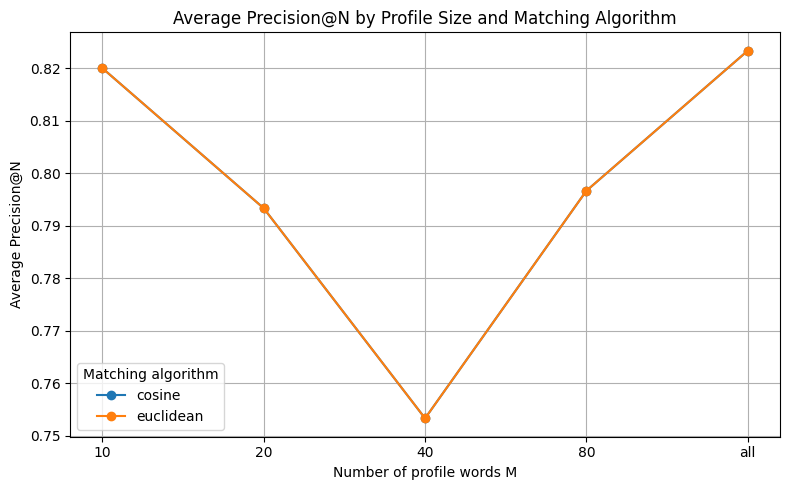

In [272]:
precision_pivot = overall_metrics_by_algorithm_M.pivot(
    index="M_label",
    columns="algorithm",
    values="avg_precision_at_N"
).reindex(M_LABEL_ORDER)

plt.figure(figsize=(8, 5))

for algorithm in precision_pivot.columns:
    plt.plot(
        precision_pivot.index.astype(str),
        precision_pivot[algorithm],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of profile words M")
plt.ylabel("Average Precision@N")
plt.title("Average Precision@N by Profile Size and Matching Algorithm")
plt.legend(title="Matching algorithm")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Plot 2：Average liked count by M and algorithm

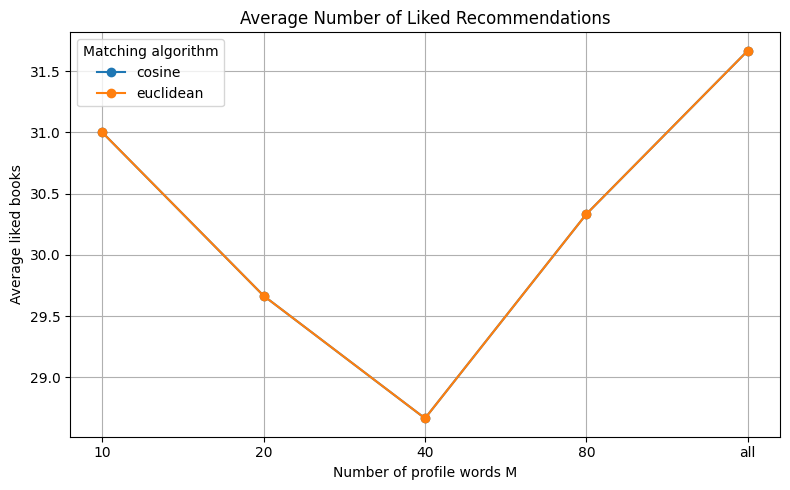

In [273]:
liked_pivot = overall_metrics_by_algorithm_M.pivot(
    index="M_label",
    columns="algorithm",
    values="avg_liked_count"
).reindex(M_LABEL_ORDER)

plt.figure(figsize=(8, 5))

for algorithm in liked_pivot.columns:
    plt.plot(
        liked_pivot.index.astype(str),
        liked_pivot[algorithm],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of profile words M")
plt.ylabel("Average liked books")
plt.title("Average Number of Liked Recommendations")
plt.legend(title="Matching algorithm")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Plot 3：Average Recall@N by M and algorithm

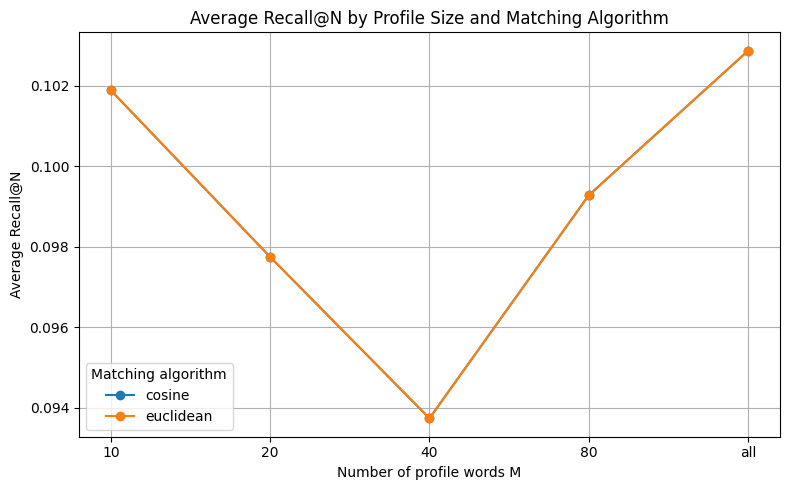

In [274]:
recall_pivot = overall_metrics_by_algorithm_M.pivot(
    index="M_label",
    columns="algorithm",
    values="avg_recall_at_N"
).reindex(M_LABEL_ORDER)

plt.figure(figsize=(8, 5))

for algorithm in recall_pivot.columns:
    plt.plot(
        recall_pivot.index.astype(str),
        recall_pivot[algorithm],
        marker="o",
        label=algorithm
    )

plt.xlabel("Number of profile words M")
plt.ylabel("Average Recall@N")
plt.title("Average Recall@N by Profile Size and Matching Algorithm")
plt.legend(title="Matching algorithm")
plt.grid(True)
plt.tight_layout()
plt.show()

In [275]:
best_setting = overall_metrics_by_algorithm_M.sort_values(
    by=["avg_precision_at_N", "avg_liked_count", "avg_recall_at_N"],
    ascending=False
).iloc[0]

print("Best overall setting:")
print(best_setting)

Best overall setting:
algorithm                cosine
M                           all
avg_shown_count            40.0
avg_liked_count       31.666667
avg_precision_at_N     0.823333
avg_hit_rate_at_N           1.0
avg_recall_at_N        0.102865
M_label                     all
Name: 0, dtype: object


In [ ]:
best_algorithm = best_setting["algorithm"]
best_M = best_setting["M"]

best_setting_user_table = recommendation_metrics_df[
    (recommendation_metrics_df["algorithm"] == best_algorithm) &
    (recommendation_metrics_df["M"] == best_M)
].copy()

best_setting_user_table = best_setting_user_table[
    [
        "user",
        "algorithm",
        "M",
        "shown_count",
        "liked_count",
        "precision_at_N",
        "hit_rate_at_N",
        "recall_at_N"
    ]
].sort_values("user").reset_index(drop=True)

best_setting_user_table

,user,algorithm,M,shown_count,liked_count,precision_at_N,hit_rate_at_N,recall_at_N
0,User1,cosine,all,50,40,0.80,1.0,0.128205
1,User2,cosine,all,20,19,0.95,1.0,0.079832
2,User3,cosine,all,50,36,0.72,1.0,0.100559


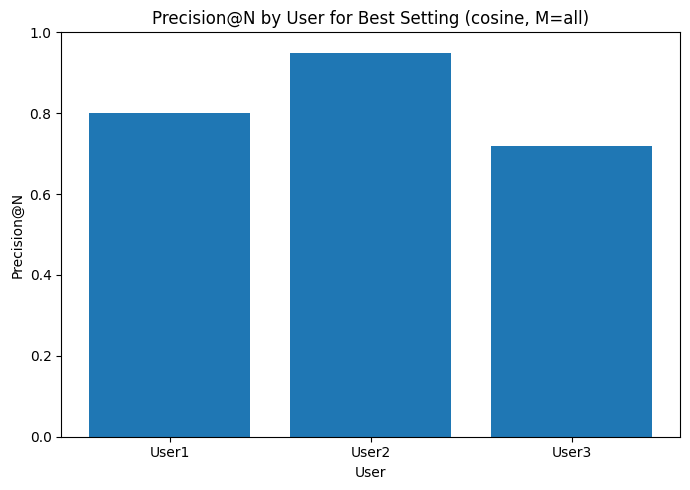

In [277]:
plt.figure(figsize=(7, 5))

plt.bar(
    best_setting_user_table["user"],
    best_setting_user_table["precision_at_N"]
)

plt.xlabel("User")
plt.ylabel("Precision@N")
plt.title(f"Precision@N by User for Best Setting ({best_algorithm}, M={best_M})")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

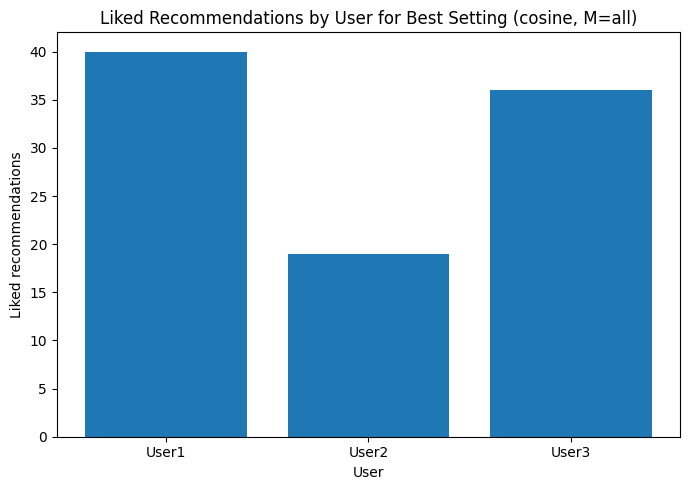

In [278]:
plt.figure(figsize=(7, 5))

plt.bar(
    best_setting_user_table["user"],
    best_setting_user_table["liked_count"]
)

plt.xlabel("User")
plt.ylabel("Liked recommendations")
plt.title(f"Liked Recommendations by User for Best Setting ({best_algorithm}, M={best_M})")
plt.tight_layout()
plt.show()